<a href="https://colab.research.google.com/github/agalya-data-analyst/Inventory-Optimization-Analysis/blob/main/Supplychain_Inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Channel Supply Chain Warehouse Inventory & Safety Stock Framework**

### **Objective**

**Sales Trend Analysis & Demand Forecasting**

* Identifying which product categories sell the most during specific months.
* Tracking how much promotions increase overall sales.

**Inventory Optimization & Stockouts Avoidance**

* Comparing Qty on Hand against Qty Sold to identify stores facing stockout risks or holding slow-moving inventory.
* Establishing optimal safety stock levels.

**Profitability & Business Margin Analysis**

* Measuring true business profitability by calculating net profit margins ($\text{Sales Amount} - \text{COGS}$) across different product segments.

* Identifying which stores and sales channels are performing the best financially.
* Evaluating and quantifying the financial impact of customer product returns on overall profits.



### **Dataset Information**

Source: Mendeley Data Repository.

Location:  USA Retail Market

Year/Timeline: Data collected during the period 2025 to 2026.

Domain: Retail, Supply Chain, and Inventory Management.

In [1]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
import io
import zipfile
import requests
#Raw Link of Github Zip file
zip_url = "https://github.com/agalya-data-analyst/Inventory-Optimization-Analysis/raw/refs/heads/main/data/raw_data.zip.zip"

#Downloading zip file from link
response = requests.get(zip_url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

#Extracting CSV files from Zip file
zip_file.extractall()


#Finding files in zip file
print("Files inside zip:")
print(zip_file.namelist())



Files inside zip:
['retail_sales_ml_apl.csv', 'retail_inventory_ml_apl.csv']


In [3]:
#csv file is converted into Data Frame using pandas

df_inventory = pd.read_csv("retail_inventory_ml_apl.csv")

df_sales = pd.read_csv("retail_sales_ml_apl.csv")

### **Initial Inspection / Initial EDA**

#Inventory

In [4]:
#Seeing the Sample

df_inventory.head()

,Start Date,End Date,Stock Status,Supplier,Product No,Product Description,Product Division,Product Category,Product Subcategory,Product Segment,Store,Store Type,Sales Channel,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price
0,07-08-2025,18-10-2025,Full Price,Vendor 0255,PROD-159369,PROD-103395 SEG-500461 Scholar Footwear Canvas...,Scholar Footwear,Scholar Footwear Canvas Styles,Scholar Footwear Canvas Styles Drifter,SEG-500461 Scholar Footwear Canvas Styles Drifter,STR-1010,Retail Storefront,Channel Alpha,1,55.0,24.75,55.0,24.75
1,15-02-2026,15-02-2026,Full Price,Vendor 0010,PROD-180713,PROD-190644 SEG-520887 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Trident,SEG-520887 Femme Footwear Court Casual Trident,STR-1082,Retail Storefront,Channel Alpha,1,130.0,59.73,130.0,59.73
2,08-01-2026,15-02-2026,Full Price,Vendor 0166,PROD-169474,PROD-153439 SEG-512518 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-512518 Femme Footwear Court Casual Zephyr,STR-1105,Retail Storefront,Channel Alpha,1,120.0,60.44,120.0,60.44
3,23-12-2025,15-02-2026,Full Price,Vendor 0106,PROD-170976,PROD-122029 SEG-504463 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-504463 Junior Apparel Cozy Pullovers Varied,STR-1157,Retail Storefront,Channel Alpha,3,150.0,52.50,50.0,17.50
4,10-02-2026,31-12-9999,Full Price,Vendor 0134,PROD-183525,PROD-111954 SEG-502325 Scholar Footwear Modern...,Scholar Footwear,Scholar Footwear Modern Legend,Scholar Footwear Modern Legend Summit,SEG-502325 Scholar Footwear Modern Legend Summit,STR-1253,Retail Storefront,Channel Alpha,4,360.0,182.16,90.0,45.54


In [5]:
#Checking Data Structure

df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284755 entries, 0 to 284754
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Start Date                284755 non-null  object 
 1   End Date                  284755 non-null  object 
 2   Stock Status              284755 non-null  object 
 3   Supplier                  284755 non-null  object 
 4   Product No                284755 non-null  object 
 5   Product Description       284755 non-null  object 
 6   Product Division          284755 non-null  object 
 7   Product Category          284755 non-null  object 
 8   Product Subcategory       284755 non-null  object 
 9   Product Segment           284755 non-null  object 
 10  Store                     284755 non-null  object 
 11  Store Type                284755 non-null  object 
 12  Sales Channel             284755 non-null  object 
 13  Qty on hand               284755 non-null  i

In [6]:
#Checking Column Names

df_inventory.columns

Index(['Start Date', 'End Date', 'Stock Status', 'Supplier', 'Product No',
       'Product Description', 'Product Division', 'Product Category',
       'Product Subcategory', 'Product Segment', 'Store', 'Store Type',
       'Sales Channel', 'Qty on hand', 'Stocks Selling Amount',
       'Cost of Stocks', 'Stock Unit Selling Price', 'Stock Unit Cost Price'],
      dtype='object')

In [7]:
#Quick Math Summary

df_inventory.describe()

,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price
count,284755.000000,284755.000000,284755.000000,284755.000000,284755.000000
mean,2.294629,224.392566,111.046256,95.313171,47.419488
std,2.007395,214.479811,105.785092,46.655771,23.776569
min,-9.000000,-828.000000,-418.950000,0.000000,-16.940000
25%,1.000000,95.000000,46.430000,75.000000,37.950000
50%,2.000000,160.000000,80.960000,100.000000,50.050000
75%,3.000000,300.000000,149.170000,120.000000,60.720000
max,56.000000,5600.000000,2641.450000,250.000000,336.380000


In [8]:
#Checking datatypes

df_inventory.dtypes

,0
Start Date,object
End Date,object
Stock Status,object
Supplier,object
Product No,object
Product Description,object
Product Division,object
Product Category,object
Product Subcategory,object
Product Segment,object


In [9]:
#Finding Repeat Rows

df_inventory.duplicated().sum()

np.int64(0)

In [10]:
#Finding Empty Cells

df_inventory.isnull().sum()

,0
Start Date,0
End Date,0
Stock Status,0
Supplier,0
Product No,0
Product Description,0
Product Division,0
Product Category,0
Product Subcategory,0
Product Segment,0


In [11]:
#Checking number of rows and columns

df_inventory.shape

(284755, 18)

#Sales

In [12]:
#Seeing the Sample

df_sales.head()

,Transaction Date,Sales Type,Is Return,Reason of Return,Supplier,Product No,Product Description,Product Division,Product Category,Product Subcategory,Product Segment,Store,Sales Channel,Qty Sold,Sales Amount,Cogs,Number of Transactions
0,01-09-2025,Full Price,0,NaN,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,STR-1006,Channel Alpha,1,115.00,52.31,1
1,07-09-2025,Full Price,0,NaN,Vendor 0166,PROD-100449,PROD-100825 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,STR-1198,Channel Alpha,1,115.00,58.47,1
2,06-08-2025,Promo,0,NaN,Vendor 0169,PROD-153623,PROD-148813 SEG-511388 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-511388 Scholar Footwear Trailblazer Equili...,STR-1157,Channel Alpha,1,79.99,43.76,1
3,31-08-2025,Full Price,0,NaN,Vendor 0246,PROD-140876,PROD-100419 SEG-500063 Scholar Footwear Boot C...,Scholar Footwear,Scholar Footwear Boot Collection,Scholar Footwear Boot Collection Woodland,SEG-500063 Scholar Footwear Boot Collection Wo...,STR-1234,Channel Alpha,1,110.00,50.60,1
4,22-03-2026,Full Price,0,NaN,Vendor 0169,PROD-166113,PROD-149345 SEG-511444 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Equilibrium,SEG-511444 Femme Footwear Trailblazer Equilibrium,STR-1157,Channel Alpha,1,160.00,77.95,1


In [13]:
#Checking Data Structure

df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125751 entries, 0 to 125750
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction Date        125751 non-null  object 
 1   Sales Type              125751 non-null  object 
 2   Is Return               125751 non-null  int64  
 3   Reason of Return        0 non-null       float64
 4   Supplier                125751 non-null  object 
 5   Product No              125751 non-null  object 
 6   Product Description     125751 non-null  object 
 7   Product Division        125751 non-null  object 
 8   Product Category        125751 non-null  object 
 9   Product Subcategory     125751 non-null  object 
 10  Product Segment         125751 non-null  object 
 11  Store                   125751 non-null  object 
 12  Sales Channel           125751 non-null  object 
 13  Qty Sold                125751 non-null  int64  
 14  Sales Amount        

In [14]:
#Checking Column Names

df_sales.columns

Index(['Transaction Date', 'Sales Type', 'Is Return', 'Reason of Return',
       'Supplier', 'Product No', 'Product Description', 'Product Division',
       'Product Category', 'Product Subcategory', 'Product Segment', 'Store',
       'Sales Channel', 'Qty Sold', 'Sales Amount', 'Cogs',
       'Number of Transactions'],
      dtype='object')

In [15]:
#Quick Math Summary

df_sales.describe()

,Is Return,Reason of Return,Qty Sold,Sales Amount,Cogs,Number of Transactions
count,125751.00000,0.0,125751.000000,125751.000000,125751.000000,125751.000000
mean,0.05957,NaN,0.930370,83.356079,46.502621,1.042695
std,0.23669,NaN,0.586897,83.658776,43.597511,0.305832
min,0.00000,NaN,-3.000000,-380.000000,-192.280000,1.000000
25%,0.00000,NaN,1.000000,50.000000,37.710000,1.000000
50%,0.00000,NaN,1.000000,90.000000,50.050000,1.000000
75%,0.00000,NaN,1.000000,115.000000,60.720000,1.000000
max,1.00000,NaN,14.000000,2660.000000,1345.960000,14.000000


In [16]:
#Checking datatypes

df_sales.dtypes

,0
Transaction Date,object
Sales Type,object
Is Return,int64
Reason of Return,float64
Supplier,object
Product No,object
Product Description,object
Product Division,object
Product Category,object
Product Subcategory,object


In [17]:
#Finding Repeat Rows

df_sales.duplicated().sum()

np.int64(0)

In [18]:
#Finding Empty Cells

df_sales.isnull().sum()

,0
Transaction Date,0
Sales Type,0
Is Return,0
Reason of Return,125751
Supplier,0
Product No,0
Product Description,0
Product Division,0
Product Category,0
Product Subcategory,0


In [19]:
#Checking number of rows and columns

df_sales.shape

(125751, 17)

##**Data Cleaning**

#Inventory

In [20]:
#checking duplicate rows

df_inventory.duplicated().sum()

np.int64(0)

In [21]:
#Checking empty cells

df_inventory.isnull().sum()

,0
Start Date,0
End Date,0
Stock Status,0
Supplier,0
Product No,0
Product Description,0
Product Division,0
Product Category,0
Product Subcategory,0
Product Segment,0


In [22]:
#Cleaning unwanted spaces in keys

df_inventory['Product No'] = df_inventory['Product No'].str.strip()

df_inventory['Store'] = df_inventory['Store'].str.strip()

In [23]:
#Checking unique values(for cases)

print("Product categories:")

print(df_inventory['Product Category'].unique())

print("Store Type:")
print(df_inventory["Store Type"].unique())

print("Sales Channel:")

print(df_inventory['Sales Channel'].unique())

Product categories:
['Scholar Footwear Canvas Styles' 'Femme Footwear Court Casual'
 'Junior Apparel Cozy Pullovers' 'Scholar Footwear Modern Legend'
 'Scholar Footwear Flight Classic' 'Scholar Footwear Court Casual'
 'Scholar Footwear Sandals' 'Junior Apparel Cozy Trousers'
 'Scholar Footwear Trailblazer' 'Junior Apparel Trousers'
 'Junior Apparel Printed Tees' 'Scholar Footwear Retro Legend'
 'Scholar Footwear Boot Collection' 'Junior Apparel Crew Tees'
 'Junior Apparel Crop Pants' 'Femme Footwear Boot Collection'
 'Femme Footwear Trailblazer' 'Femme Footwear Retro Legend'
 'Femme Footwear Flight Classic' 'Junior Apparel Gift Bundles'
 'Junior Apparel Denim Classics' 'Scholar Footwear Trainer'
 'Junior Apparel Light Shells' 'Scholar Footwear Hardcourt'
 'Junior Apparel Miscellany' 'Junior Apparel Outer Shells'
 'Femme Footwear Modern Legend']
Store Type:
['Retail Storefront']
Sales Channel:
['Channel Alpha']


#Sales

In [24]:
#Cleaning unwanted spaces in keys

df_sales['Product No'] = df_sales['Product No'].str.strip()

df_sales['Store'] = df_sales['Store'].str.strip()

In [25]:
#Checking unique values(for cases)

print("Product categories:")

print(df_sales['Product Category'].unique())

print("Sales Type:")

print(df_sales['Sales Type'].unique())

print("Sales Channel:")

print(df_sales['Sales Channel'].unique())


Product categories:
['Scholar Footwear Trailblazer' 'Femme Footwear Flight Classic'
 'Scholar Footwear Boot Collection' 'Femme Footwear Trailblazer'
 'Scholar Footwear Court Casual' 'Scholar Footwear Modern Legend'
 'Junior Apparel Cozy Trousers' 'Junior Apparel Crop Pants'
 'Scholar Footwear Retro Legend' 'Scholar Footwear Flight Classic'
 'Scholar Footwear Sandals' 'Femme Footwear Court Casual'
 'Junior Apparel Printed Tees' 'Junior Apparel Cozy Pullovers'
 'Scholar Footwear Trainer' 'Junior Apparel Gift Bundles'
 'Junior Apparel Trousers' 'Femme Footwear Retro Legend'
 'Junior Apparel Crew Tees' 'Femme Footwear Modern Legend'
 'Femme Footwear Boot Collection' 'Scholar Footwear Hardcourt'
 'Scholar Footwear Canvas Styles' 'Junior Apparel Miscellany'
 'Junior Apparel Denim Classics' 'Junior Apparel Light Shells'
 'Junior Apparel Outer Shells']
Sales Type:
['Full Price' 'Promo' 'Markdown Tier 1' 'Clearance' 'Markdown Tier 2']
Sales Channel:
['Channel Alpha']


In [26]:
#Filling reason for return column

df_sales['Reason of Return'] = df_sales['Is Return'].map({0: 'Not Returned', 1: 'Returned'})



In [27]:
#verifying Is return and Reason of return column

print("Top 10 rows:\n")

print(df_sales[['Is Return','Reason of Return']].head(10))

print("Bottom 10 rows:\n")

print(df_sales[['Is Return','Reason of Return']].tail(10))

Top 10 rows:

   Is Return Reason of Return
0          0     Not Returned
1          0     Not Returned
2          0     Not Returned
3          0     Not Returned
4          0     Not Returned
5          0     Not Returned
6          0     Not Returned
7          0     Not Returned
8          0     Not Returned
9          0     Not Returned
Bottom 10 rows:

        Is Return Reason of Return
125741          0     Not Returned
125742          0     Not Returned
125743          0     Not Returned
125744          0     Not Returned
125745          1         Returned
125746          0     Not Returned
125747          0     Not Returned
125748          0     Not Returned
125749          0     Not Returned
125750          1         Returned


In [28]:
#checking empty cells in Reason of Return column

df_sales["Reason of Return"].isnull().sum()

np.int64(0)

In [29]:
df_sales['Reason of Return'].unique()

array(['Not Returned', 'Returned'], dtype=object)

## **Data Transformation**

In [30]:
# Converting Object to Datetime format

df_sales['Transaction Date'] = pd.to_datetime(df_sales['Transaction Date'],dayfirst=True,errors='coerce')

df_inventory['Start Date'] = pd.to_datetime(df_inventory['Start Date'],dayfirst=True,errors='coerce')

df_inventory['End Date'] = pd.to_datetime(df_inventory['End Date'], dayfirst=True,errors='coerce')

# Renaming Column for Standardization

df_sales = df_sales.rename(columns={'Cogs': 'COGS'})


In [31]:
# checking data types of inventory

df_inventory[['Start Date','End Date']].dtypes



,0
Start Date,datetime64[ns]
End Date,datetime64[ns]


In [32]:
#checking data types of transaction date colum

df_sales[['Transaction Date']].dtypes

,0
Transaction Date,datetime64[ns]


In [33]:
#checking column name 'cogs'

df_sales.columns

Index(['Transaction Date', 'Sales Type', 'Is Return', 'Reason of Return',
       'Supplier', 'Product No', 'Product Description', 'Product Division',
       'Product Category', 'Product Subcategory', 'Product Segment', 'Store',
       'Sales Channel', 'Qty Sold', 'Sales Amount', 'COGS',
       'Number of Transactions'],
      dtype='object')

## **Feature Engineering**

In [34]:
#Creating new column "Profit"

df_sales['Profit'] = df_sales['Sales Amount']-df_sales['COGS']
df_sales['Profit']

,Profit
0,62.69
1,56.53
2,36.23
3,59.40
4,82.05
...,...
125746,59.95
125747,20.82
125748,73.30
125749,45.45


In [35]:
#Extracting month-column and year-column from transaction date column

df_sales['Month'] = df_sales['Transaction Date'].dt.month_name()

df_sales['Year'] = df_sales['Transaction Date'].dt.year

print(df_sales['Month'].head(5))

print(df_sales['Year'].head(5))

0    September
1    September
2       August
3       August
4        March
Name: Month, dtype: object
0    2025
1    2025
2    2025
3    2025
4    2026
Name: Year, dtype: int32


In [36]:
#Merging Sales and Inventory tables using common keys

df_merged = pd.merge(df_sales, df_inventory, on=['Product No', 'Store'], how='inner')

df_merged.head(5)

,Transaction Date,Sales Type,Is Return,Reason of Return,Supplier_x,Product No,Product Description_x,Product Division_x,Product Category_x,Product Subcategory_x,...,Product Category_y,Product Subcategory_y,Product Segment_y,Store Type,Sales Channel_y,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price
0,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,Retail Storefront,Channel Alpha,0,0.0,0.11,0.0,0.000
1,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,Retail Storefront,Channel Alpha,6,690.0,313.95,115.0,52.325
2,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,Retail Storefront,Channel Alpha,0,0.0,0.11,0.0,0.000
3,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,Retail Storefront,Channel Alpha,3,345.0,157.02,115.0,52.340
4,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,Retail Storefront,Channel Alpha,6,690.0,313.95,115.0,52.325


In [37]:
#To check number of rows and columns of new formed table

print(df_merged.shape)

#Checking whether column product category_x and column product category_y is with same data or different

mismatched_rows = df_merged[df_merged['Product Category_x'] != df_merged['Product Category_y']]

print(f"Mismatched rows between product category_x and product category_y:{len(mismatched_rows)}")




(1166893, 36)
Mismatched rows between product category_x and product category_y:0


In [38]:
#Removing duplicate columns from merged table
columns_to_remove = [
    'Supplier_y',
    'Product Description_y',
    'Product Division_y',
    'Product Category_y',
    'Product Subcategory_y',
    'Product Segment_y',
    'Sales Channel_y',
]
#Drop comment

df_merged = df_merged.drop(columns=columns_to_remove)


#Renaming the columns ends with'x'

rename_columns = {
    'Supplier_x': 'Supplier',
    'Product Description_x': 'Product Description',
    'Product Division_x': 'Product Division',
    'Product Category_x': 'Product Category',
    'Product Subcategory_x': 'Product Subcategory',
    'Product Segment_x': 'Product Segment',
    'Sales Channel_x': 'Sales Channel'
}
#Rename comment

df_merged = df_merged.rename(columns=rename_columns)



In [39]:
#Creating KPI columns

#Creating "Stock Status Alert"column

df_merged['Stock_Status_Alert'] = np.where(df_merged['Qty on hand'] < df_merged['Qty Sold'], 'Stockout Risk', 'Safe Stock')

df_merged['Stock_Status_Alert'].head(20)

,Stock_Status_Alert
0,Stockout Risk
1,Safe Stock
2,Stockout Risk
3,Safe Stock
4,Safe Stock
5,Safe Stock
6,Safe Stock
7,Safe Stock
8,Safe Stock
9,Safe Stock


In [40]:
#Fixing Inventory Turnover index

df_merged['Inventory_Turnover_Index'] = df_merged['COGS'] / df_merged['Cost of Stocks']

df_merged['Inventory_Turnover_Index'].head(10)

,Inventory_Turnover_Index
0,475.545455
1,0.166619
2,475.545455
3,0.333142
4,0.166619
5,0.499332
6,0.998092
7,0.199931
8,0.997902
9,0.249893


In [41]:
#checking

display(df_merged[['Product No', 'Store', 'Qty Sold', 'Qty on hand', 'Is Return', 'Stock_Status_Alert']].head(3))

,Product No,Store,Qty Sold,Qty on hand,Is Return,Stock_Status_Alert
0,PROD-139867,STR-1006,1,0,0,Stockout Risk
1,PROD-139867,STR-1006,1,6,0,Safe Stock
2,PROD-139867,STR-1006,1,0,0,Stockout Risk


## **Final Inspection/Final EDA**

In [42]:
#Data Frame information

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166893 entries, 0 to 1166892
Data columns (total 31 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   Transaction Date          1166893 non-null  datetime64[ns]
 1   Sales Type                1166893 non-null  object        
 2   Is Return                 1166893 non-null  int64         
 3   Reason of Return          1166893 non-null  object        
 4   Supplier                  1166893 non-null  object        
 5   Product No                1166893 non-null  object        
 6   Product Description       1166893 non-null  object        
 7   Product Division          1166893 non-null  object        
 8   Product Category          1166893 non-null  object        
 9   Product Subcategory       1166893 non-null  object        
 10  Product Segment           1166893 non-null  object        
 11  Store                     1166893 non-null  object

In [43]:
#Displaying top5 rows

df_merged.head()

,Transaction Date,Sales Type,Is Return,Reason of Return,Supplier,Product No,Product Description,Product Division,Product Category,Product Subcategory,...,End Date,Stock Status,Store Type,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price,Stock_Status_Alert,Inventory_Turnover_Index
0,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-11-13,Full Price,Retail Storefront,0,0.0,0.11,0.0,0.000,Stockout Risk,475.545455
1,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-07-30,Full Price,Retail Storefront,6,690.0,313.95,115.0,52.325,Safe Stock,0.166619
2,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-10-01,Full Price,Retail Storefront,0,0.0,0.11,0.0,0.000,Stockout Risk,475.545455
3,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-09-12,Full Price,Retail Storefront,3,345.0,157.02,115.0,52.340,Safe Stock,0.333142
4,2025-09-01,Full Price,0,Not Returned,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-08-16,Full Price,Retail Storefront,6,690.0,313.95,115.0,52.325,Safe Stock,0.166619


In [44]:
#displaying last 5 rows

df_merged.tail()

,Transaction Date,Sales Type,Is Return,Reason of Return,Supplier,Product No,Product Description,Product Division,Product Category,Product Subcategory,...,End Date,Stock Status,Store Type,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price,Stock_Status_Alert,Inventory_Turnover_Index
1166888,2025-07-16,Full Price,1,Returned,Vendor 0169,PROD-165957,PROD-102502 SEG-500344 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-07-16,Full Price,Retail Storefront,3,255.0,116.03,85.0,38.6767,Safe Stock,-0.333362
1166889,2025-07-16,Full Price,1,Returned,Vendor 0169,PROD-165957,PROD-102502 SEG-500344 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-08-12,Full Price,Retail Storefront,1,85.0,38.67,85.0,38.6700,Safe Stock,-1.000259
1166890,2025-07-16,Full Price,1,Returned,Vendor 0169,PROD-165957,PROD-102502 SEG-500344 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-07-26,Full Price,Retail Storefront,2,170.0,77.35,85.0,38.6750,Safe Stock,-0.500065
1166891,2025-07-16,Full Price,1,Returned,Vendor 0169,PROD-165957,PROD-102502 SEG-500344 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-07-27,Full Price,Retail Storefront,2,170.0,77.35,85.0,38.6750,Safe Stock,-0.500065
1166892,2025-07-16,Full Price,1,Returned,Vendor 0169,PROD-165957,PROD-102502 SEG-500344 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,...,2025-08-11,Full Price,Retail Storefront,1,85.0,38.67,85.0,38.6700,Safe Stock,-1.000259


In [45]:
#Display data frame shape

df_merged.shape

(1166893, 31)

In [46]:
#Data Frame data types

df_merged.dtypes

,0
Transaction Date,datetime64[ns]
Sales Type,object
Is Return,int64
Reason of Return,object
Supplier,object
Product No,object
Product Description,object
Product Division,object
Product Category,object
Product Subcategory,object


In [47]:
#Checking for duplicate records

df_merged.duplicated().sum()

np.int64(0)

In [48]:
#Checking for null values

df_merged.isnull().sum()

,0
Transaction Date,0
Sales Type,0
Is Return,0
Reason of Return,0
Supplier,0
Product No,0
Product Description,0
Product Division,0
Product Category,0
Product Subcategory,0


In [49]:
# Converting End date column from date format to text format and filling empty cells with "Active"

df_merged['End Date'] = df_merged['End Date'].dt.strftime('%Y-%m-%d').fillna('Active')

#checking null values in End date column

print(df_merged['End Date'].isnull().sum())

0


In [50]:
#Statistical summary after cleaning and transformation of data

df_merged.describe()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,Transaction Date,Is Return,Qty Sold,Sales Amount,COGS,Number of Transactions,Profit,Year,Start Date,Qty on hand,Stocks Selling Amount,Cost of Stocks,Stock Unit Selling Price,Stock Unit Cost Price,Inventory_Turnover_Index
count,1166893,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1166893,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06,1.166893e+06
mean,2025-11-20 06:14:57.157836544,6.190713e-02,9.402327e-01,8.567177e+01,4.534187e+01,1.056786e+00,4.032990e+01,2.025328e+03,2025-11-01 18:51:54.479904512,3.542962e+00,3.417106e+02,1.665233e+02,9.414727e+01,4.599899e+01,NaN
min,2025-06-01 00:00:00,0.000000e+00,-3.000000e+00,-3.800000e+02,-1.922800e+02,1.000000e+00,-2.004500e+02,2.025000e+03,2025-06-01 00:00:00,-9.000000e+00,-8.280000e+02,-4.189500e+02,0.000000e+00,-1.694000e+01,-inf
25%,2025-08-30 00:00:00,0.000000e+00,1.000000e+00,6.999000e+01,4.356000e+01,1.000000e+00,2.230000e+01,2.025000e+03,2025-08-17 00:00:00,1.000000e+00,1.150000e+02,5.511000e+01,9.000000e+01,4.356000e+01,1.676975e-01
50%,2025-11-29 00:00:00,0.000000e+00,1.000000e+00,9.000000e+01,4.629000e+01,1.000000e+00,4.446000e+01,2.025000e+03,2025-10-31 00:00:00,3.000000e+00,2.400000e+02,1.175000e+02,9.200000e+01,4.618560e+01,3.333333e-01
75%,2026-02-06 00:00:00,0.000000e+00,1.000000e+00,1.150000e+02,5.808000e+01,1.000000e+00,5.995000e+01,2.026000e+03,2026-01-07 00:00:00,5.000000e+00,4.650000e+02,2.279600e+02,1.200000e+02,5.508330e+01,6.073239e-01
max,2026-04-24 00:00:00,1.000000e+00,1.400000e+01,2.660000e+03,1.345960e+03,1.400000e+01,1.314040e+03,2.026000e+03,2026-04-24 00:00:00,5.600000e+01,5.600000e+03,2.641450e+03,2.500000e+02,3.363800e+02,inf
std,NaN,2.409869e-01,5.935744e-01,7.331812e+01,3.722908e+01,2.965435e-01,3.906174e+01,4.695578e-01,NaN,3.191694e+00,3.175026e+02,1.539204e+02,3.960351e+01,1.986865e+01,NaN


## **Statistical Analysis**

In [51]:
#Replacing infinite values in Inventory_Turnover_Index to Nan


df_merged['Inventory_Turnover_Index'] = df_merged['Inventory_Turnover_Index'].replace([np.inf, -np.inf], np.nan)

#Then replacing "Nan" with"0"

df_merged['Inventory_Turnover_Index'] = df_merged['Inventory_Turnover_Index'].fillna(0)

In [52]:
#Selecting our main retail columns
retail_cols = ['Qty Sold', 'Sales Amount', 'Qty on hand', 'Inventory_Turnover_Index']

#Calculating Mean, Median, and Mode in one table
summary_table = pd.DataFrame({
    'Mean': df_merged[retail_cols].mean(),
    'Median': df_merged[retail_cols].median(),
    'Mode': df_merged[retail_cols].mode().iloc[0]
})

print("MEASURE OF CENTRAL TENDENCY FOR RETAIL\n",summary_table)


MEASURE OF CENTRAL TENDENCY FOR RETAIL
                                Mean     Median  Mode
Qty Sold                   0.940233   1.000000   1.0
Sales Amount              85.671775  90.000000  90.0
Qty on hand                3.542962   3.000000   1.0
Inventory_Turnover_Index  -2.974337   0.333333   1.0


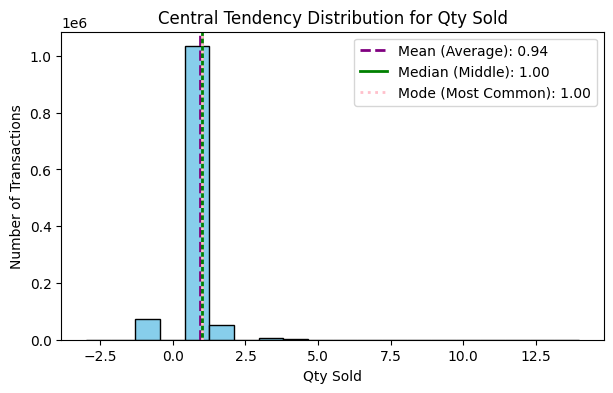

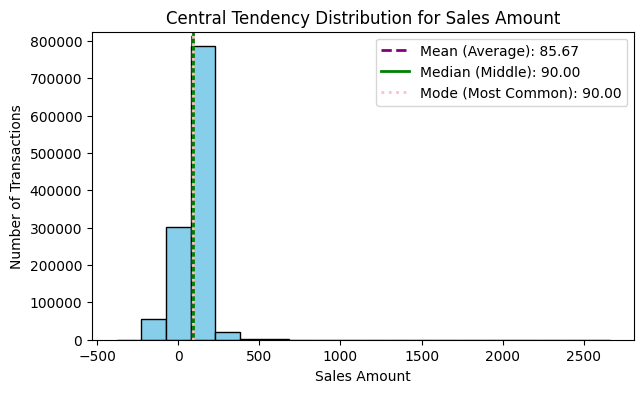

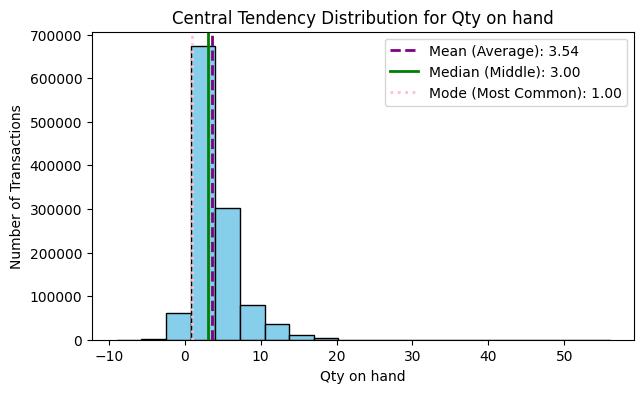

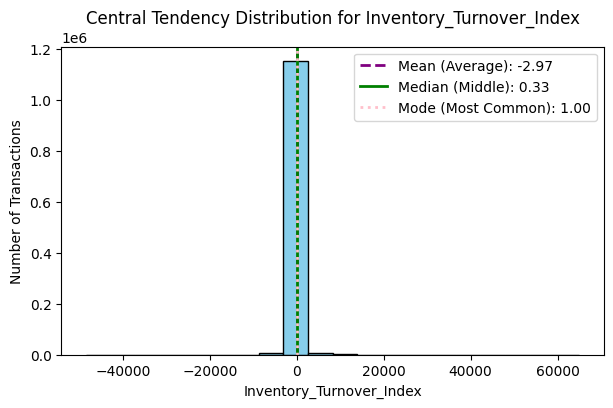

In [53]:
#For Loop to make a chart for each of the 4 columns automatically
for col in retail_cols:

    # Getting the calculated values from summary table
    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    # Setting the chart canvas size
    plt.figure(figsize=(7, 4))

    # Drawing the blue frequency bars and the smooth distribution curve
    plt.hist(df_merged[col], bins=20, color='skyblue', edgecolor='black')

    # Drawing straight vertical lines for Mean, Median, and Mode
    plt.axvline(mean_val, color='purple', linestyle='--', linewidth=2, label=f'Mean (Average): {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median (Middle): {median_val:.2f}')
    plt.axvline(mode_val, color='pink', linestyle=':', linewidth=2, label=f'Mode (Most Common): {mode_val:.2f}')

    # Adding titles and clean text labels
    plt.title(f'Central Tendency Distribution for {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Transactions')
    plt.legend()

    #Viewing the chart
    plt.show()

#####**Interpretation: Measure of Central Tendency Analysis**
The Blue Bars: Show the overall pattern and spread of our everyday retail store metrics.

The Pink Line (Mode): Points out the most frequent choice or status in our data (like the most common number of items bought per order).

The Green Line (Median): Represents our true middle ground, giving us a realistic baseline for normal store performance.

The Purple Line (Mean): Shows our mathematical average. For metrics like Sales Amount and Inventory_Turnover_Index, the Purple Mean line sits away from the Green Median line. This proves our data is skewed because extreme outliers—such as heavy bulk orders or negative customer returns—are actively pulling our overall store averages out of their natural center.

Insights:

* **Customer Returns:** The negative bars on the charts clearly show that customer product returns are actively breaking our normal store flow.
* **Skewed Data:** The **Purple Mean line** sits away from the **Green Median line**. This proves our store averages are heavily pulled out of place by sudden huge bulk orders and product returns.
* **Buying Behavior:** Most customers prefer to buy exactly **1 item** per transaction (Mode = 1).
* **Sales Baseline:** A standard, reliable customer ticket size in our store sits at **$90.00** (Median).
* **Slow Inventory:** The massive central spike at **0.33** for Inventory Turnover tells us that a huge part of our stock is moving very slowly, locking up cash in the warehouse.

In [54]:
variance_table = df_merged[retail_cols].var().to_frame(name='Variance')

print("--- MEASURE OF DISPERSION: VARIANCE ---")
print(variance_table)

--- MEASURE OF DISPERSION: VARIANCE ---
                               Variance
Qty Sold                       0.352331
Sales Amount                5375.546883
Qty on hand                   10.186908
Inventory_Turnover_Index  505071.072547


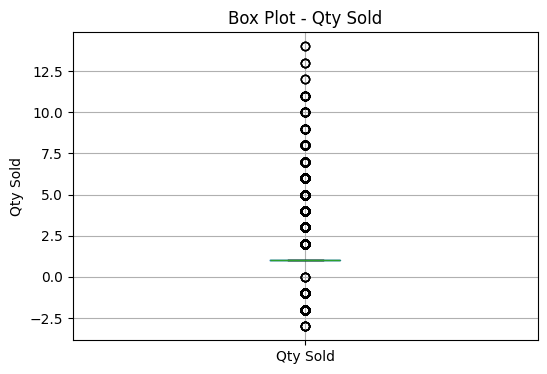

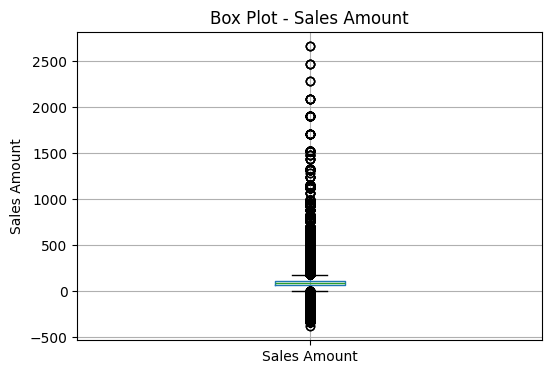

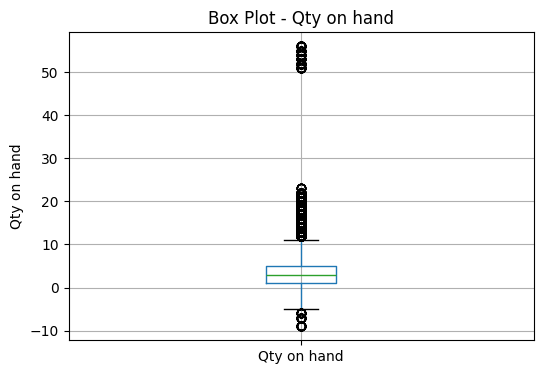

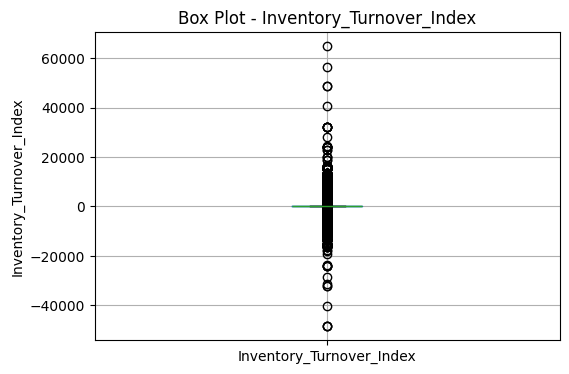

In [55]:
for col in retail_cols:
    # Set the canvas size
    plt.figure(figsize=(6, 4))

    # Draw the basic box plot using pandas
    df_merged.boxplot(column=col)

    # Add titles and y-axis labels
    plt.title(f'Box Plot - {col}')
    plt.ylabel(col)

    # Render the chart
    plt.show()

**High Dispersion (Unpredictability):** In all 4 charts (Qty Sold, Sales Amount, Qty on hand, Inventory_Turnover_Index), the long lines and massive clusters of outlier dots prove that our data has extreme variance. Our business metrics are not uniform or steady.

**Presence of Extreme Outliers:** The long trail of dots going upward shows that we have rare days with massive sales amounts and high quantities sold. These represent bulk corporate orders.

**Negative Value Anomalies:** The dots extending below zero in Qty Sold and Sales Amount visually isolate our product returns. These returns create direct financial losses and distort our operational metrics.

**Inventory Skewness:** The chart for Qty on hand shows that a few specific warehouse items are heavily overstocked (high outliers), while most items sit at a very low standard stock level.

In [56]:
std_table = df_merged[retail_cols].std().to_frame(name='STANDARD DEVIATION')

print("--- MEASURE OF DISPERSION: STANDARD DEVIATION ---")
print(std_table)

--- MEASURE OF DISPERSION: STANDARD DEVIATION ---
                          STANDARD DEVIATION
Qty Sold                            0.593574
Sales Amount                       73.318121
Qty on hand                         3.191694
Inventory_Turnover_Index          710.683525


In [57]:
# Calculating the average (mean) for our 4 retail columns
means = df_merged[retail_cols].mean()

# Subtracting the mean from each row to find the deviation
deviation = df_merged[retail_cols] - means


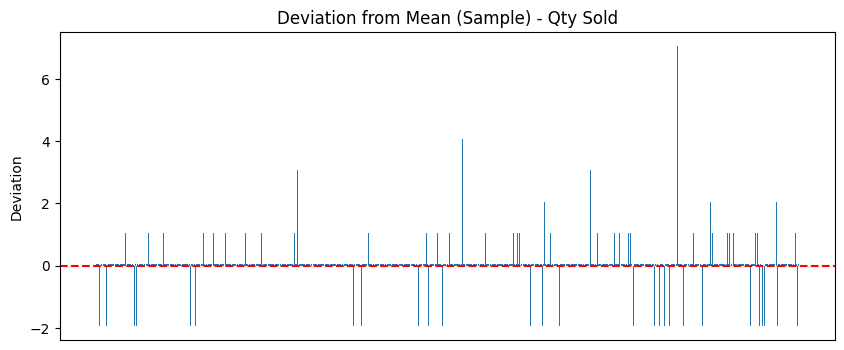

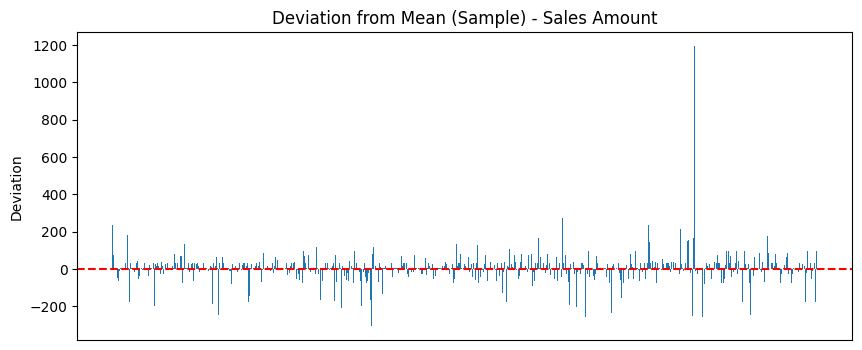

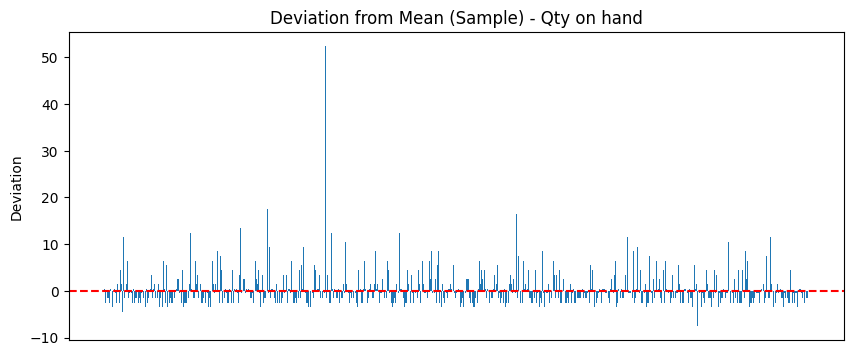

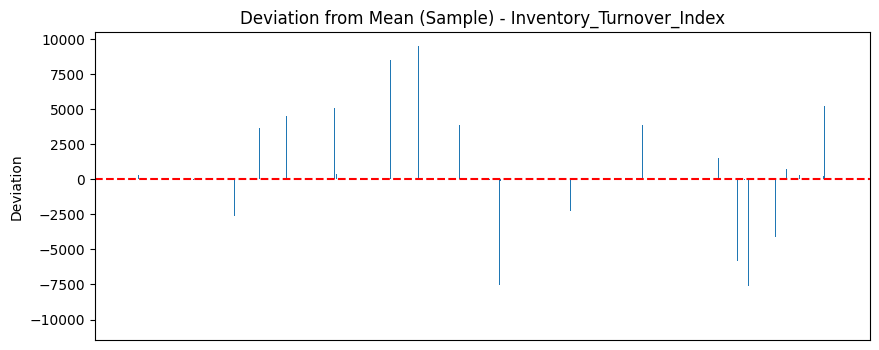

In [58]:
#Taking a random sample of 1000 rows so the chart loads instantly!
deviation_sample = deviation.sample(n=1000, random_state=42).reset_index(drop=True)

# For loop to draw the deviation chart for each column
for col in retail_cols:
    plt.figure(figsize=(10, 4))

    # Plotting deviations as bars
    plt.bar(range(len(deviation_sample)), deviation_sample[col])

    # Red dashed line represents the exact mean (0 deviation)
    plt.axhline(0, color='red', linestyle='--')

    plt.title(f'Deviation from Mean (Sample) - {col}')
    plt.ylabel('Deviation')
    plt.xticks([])  # Hiding x-axis to keep the chart clean
    plt.show()

**The Red Dashed Line (The Baseline):** The red line represents the exact average (Mean) of the data. A value right on this line means it performed exactly as expected on a normal day.

**Bars Pointing Upwards (Positive Deviation):** These vertical bars represent products or days that performed better than average. For example, the huge spikes in Sales Amount and Qty Sold show specific high-performing transactions (like bulk orders) that brought in massive unexpected revenue.

**Bars Pointing Downwards (Negative Deviation):**  These bars fall below the average. In Qty Sold and Sales Amount, these negative dips visually highlight product returns and order cancellations where we actually lost value compared to our typical daily performance.

**High Business Volatility:** Across all four metrics—especially Inventory_Turnover_Index—the constant spiking up and down shows that our retail supply chain is highly unpredictable. Sales and stock movement are not steady; they fluctuate heavily from day to day.

In [59]:
# Grouping by 'Is Return' to see the impact of returns
grouped_return = df_merged.groupby('Is Return')[retail_cols].mean()

print("--- AVERAGE RETAIL METRICS BY RETURN STATUS ---")
print(grouped_return)

--- AVERAGE RETAIL METRICS BY RETURN STATUS ---
           Qty Sold  Sales Amount  Qty on hand  Inventory_Turnover_Index
Is Return                                                               
0          1.068845     97.823405     3.552852                 -3.602188
1         -1.008652    -98.464653     3.393084                  6.539636


#####**Impact of Returns (Is Return)**

**Financial and Volume Drop**: When a product is successfully delivered (Status 0), the average Sales Amount is around 97.82, and Qty Sold is 1.06. However, when a product is returned (Status 1), both metrics drop into the negative zone ($-98.46$ and $-1.00$). This visually proves that returns create an immediate financial loss and clear inventory drain.

**Turnover Distortion**: The Inventory_Turnover_Index drops heavily into negative levels ($-3.60$) for successful orders, while returned orders show a positive value ($6.53$). This flip happens because returned items sit back in the warehouse unexpectedly, completely disrupting the natural cycle of the supply chain.

In [60]:
# Clean the column names by removing hidden spaces
df_merged.columns = df_merged.columns.str.strip()

In [61]:
# Grouping by 'Stock Status Alert' to see inventory health
grouped_alert = df_merged.groupby('Stock_Status_Alert')[retail_cols].mean()

print("--- AVERAGE RETAIL METRICS BY STOCK STATUS ALERT ---")
print(grouped_alert)

--- AVERAGE RETAIL METRICS BY STOCK STATUS ALERT ---
                    Qty Sold  Sales Amount  Qty on hand  \
Stock_Status_Alert                                        
Safe Stock          0.921514     83.451317     3.755016   
Stockout Risk       1.249392    122.345261     0.040635   

                    Inventory_Turnover_Index  
Stock_Status_Alert                            
Safe Stock                          0.873833  
Stockout Risk                     -66.531405  


 **Inventory Health (Stock Status Alert)**

 **Stockout Risk Behavior:** Items marked under Stockout Risk have a very high average Qty Sold ($1.24$) and Sales Amount ($122.34$), but their warehouse inventory (Qty on hand) is critically low near zero ($0.04$). This indicates high-demand items that are selling fast but running out of stock rapidly.

 **Safe Stock Backlog:** On the other hand, items marked as Safe Stock maintain a healthier inventory safety net (Qty on hand of $3.75$), but their sales velocity is slower.Critical Supply Chain Warning: The massive negative Inventory_Turnover_Index ($-66.53$) for Stockout Risk items is a major operational red flag. It highlights that the business is losing massive potential revenue because high-moving items are not being reordered or restocked in time.

##**Data Visualisation**

###**Multivariate Analysis**( Three or More Variable Analysis)





Sales Trend Analysis & Demand Forecasting


**Product Categories Selling Most During Specific Months (Multivariate Analysis)**

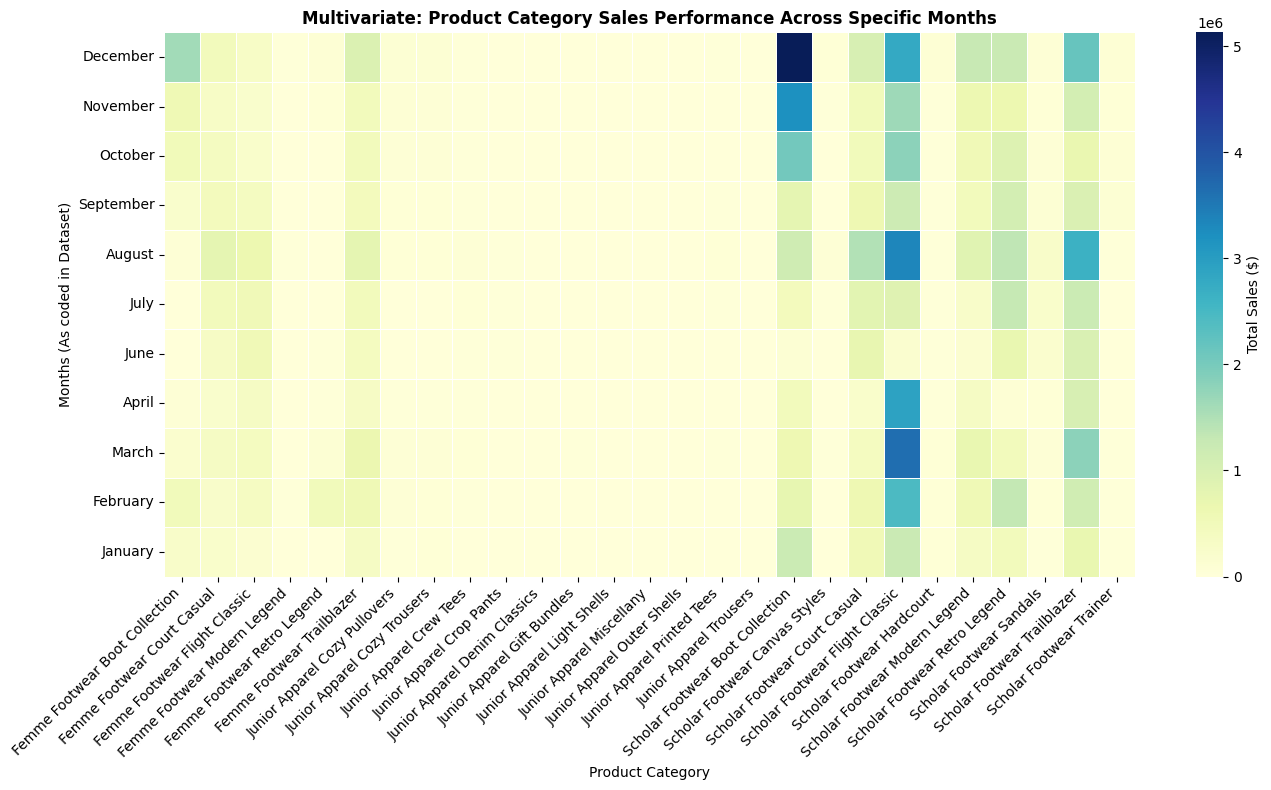

In [69]:
#To check exactly which product categories drive the highest sales amount during specific months of the year.
#Month in orders

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Group by Month and Product Category to find total Sales Amount cleanly

pivot_months = df_merged.groupby(['Month', 'Product Category'])['Sales Amount'].sum().unstack().fillna(0)

#  Automatically sort the index so we don't force a broken string

pivot_months = pivot_months.reindex(month_order).dropna(how='all')

plt.figure(figsize=(14, 8))

# Generating the heatmap with a robust colormap

# annot=False handles large matrix rendering smoothly

sns.heatmap(pivot_months, cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Total Sales ($)'})

#Inverting Y axis

plt.gca().invert_yaxis()

plt.title('Multivariate: Product Category Sales Performance Across Specific Months', fontsize=12, fontweight='bold')

plt.xlabel('Product Category')

plt.ylabel('Months (As coded in Dataset)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

###  Interpretation

This heatmap plots monthly sales performance across all product categories. Dark blue squares indicate high revenue generation, while light yellow squares represent low or zero sales.


* Top Selling Category & Peak Season: Scholar Footwear Styles experiences a massive demand surge in December ($500,000+ sales), followed by mid-year demand spikes in March and April for Scholar Footwear Flight Classic.


* Low-Demand Categories: Most Junior Apparel lines (e.g., Crop Pants, Denim Classic) remain light yellow year-round, indicating low consumer demand.


* Actionable Takeaway: Increase buffer inventory for Scholar Footwear prior to March and November to meet seasonal surges while keeping apparel inventory minimal.




**Tracking How Much Promotions Increase Overall Sales (Bivariate Analysis)**

/tmp/ipykernel_5308/2253910013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales Type', y='Sales Amount', data=df_merged, palette='Blues_d', errorbar=None)


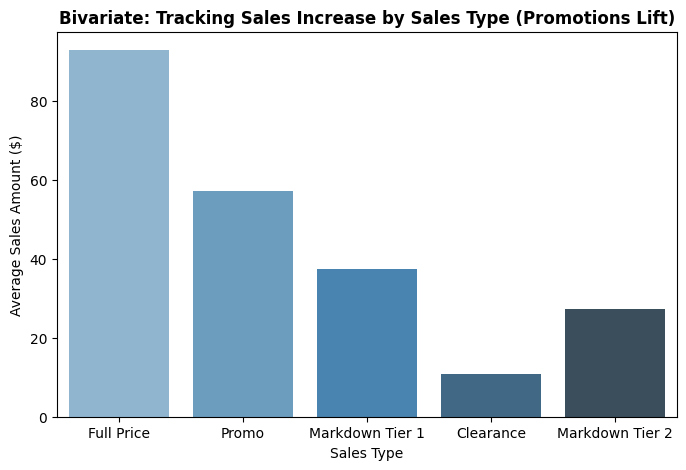

In [63]:
plt.figure(figsize=(8, 5))

# Bivariate bar chart to check average revenue change across Sales Types

sns.barplot(x='Sales Type', y='Sales Amount', data=df_merged, palette='Blues_d', errorbar=None)

plt.title('Bivariate: Tracking Sales Increase by Sales Type (Promotions Lift)', fontsize=12, fontweight='bold')

plt.xlabel('Sales Type')

plt.ylabel('Average Sales Amount ($)')

plt.show()

### Interpretation
This bar chart compares average sales revenue generated across different pricing strategies: Full Price, Promo, Markdown Tier 1, Clearance, and Markdown Tier 2.
*   Promotions Impact: Full Price sales yield the highest average revenue (~$85 per transaction), whereas promotional discounts (Promo & Markdowns) generate significantly lower average values ($20–$50).

*   Discount Effectiveness: Discounts drive order volume, but heavily reduce average basket value.

*   Actionable Takeaway: Avoid over-discounting core products. Use Markdown/Clearance tiers strictly for liquidating deadstock rather than boosting regular revenue.

Inventory Optimization & Stockouts Avoidance

**Comparing Qty on Hand vs Qty Sold by Store (Bivariate Analysis)**

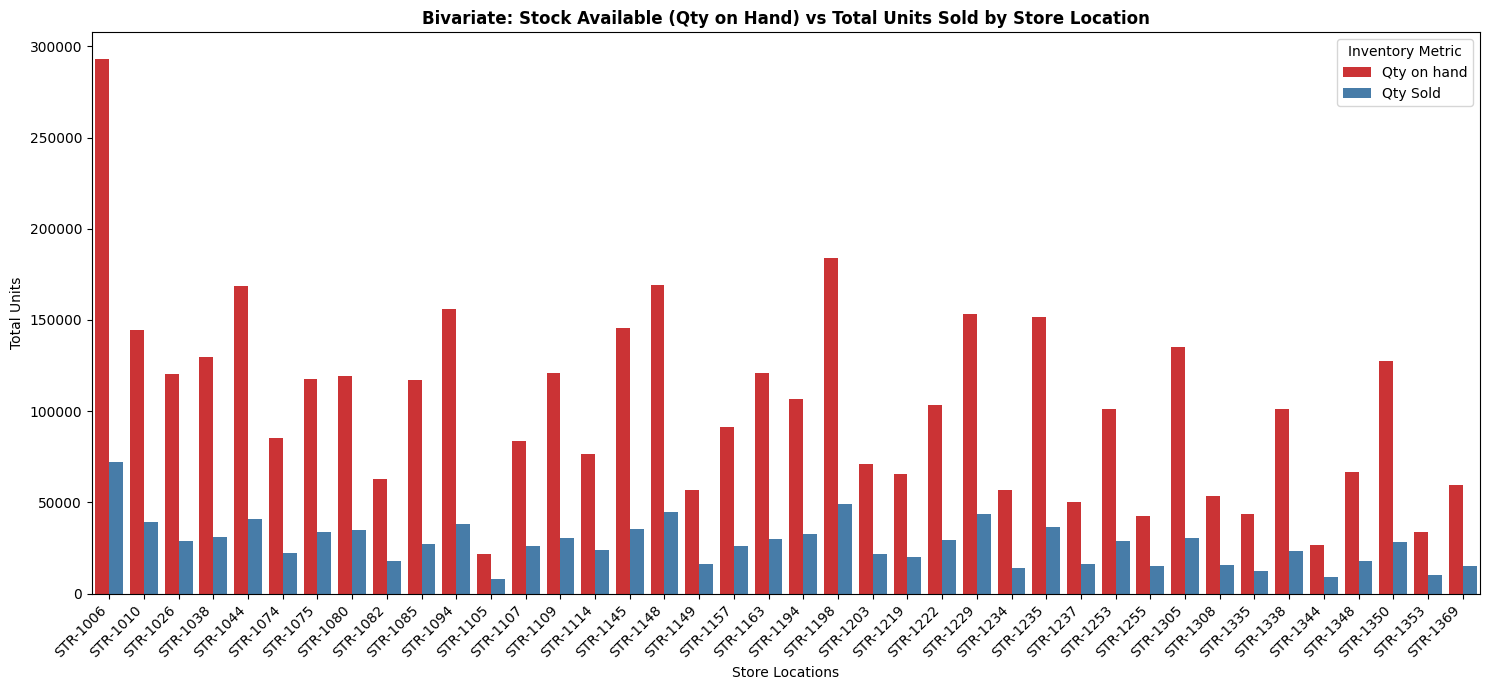

In [64]:
# 1. Aggregate volumes per store first to keep execution fast

store_inventory = df_merged.groupby('Store')[['Qty on hand', 'Qty Sold']].sum().reset_index()

# 2. Melt data to create a side-by-side grouped layout

store_inventory_melted = store_inventory.melt(id_vars='Store', value_vars=['Qty on hand', 'Qty Sold'],
                                              var_name='Inventory Metric', value_name='Total Units')

plt.figure(figsize=(15, 7))

sns.barplot(x='Store', y='Total Units', hue='Inventory Metric', data=store_inventory_melted, palette='Set1')

plt.title('Bivariate: Stock Available (Qty on Hand) vs Total Units Sold by Store Location', fontsize=12, fontweight='bold')
plt.xlabel('Store Locations')
plt.ylabel('Total Units')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation
This grouped bar chart compares available warehouse stock (Red bars) against total units sold (Blue bars) across all store locations.

* Excess Inventory & Deadstock: In almost all store locations (e.g., STR-1000, STR-1190), Qty on Hand is 3x to 5x higher than Qty Sold, indicating heavy over-stocking and tied-up working capital.

* Stockout Risk Identification: Stores where the blue bar approaches the red bar face immediate stockout risks for fast-moving SKUs.

* Actionable Takeaway: Reallocate excess stock from low-performing stores to high-demand locations before placing new vendor orders.

**Establishing Optimal Safety Stock Levels(Univariate Analysis)**

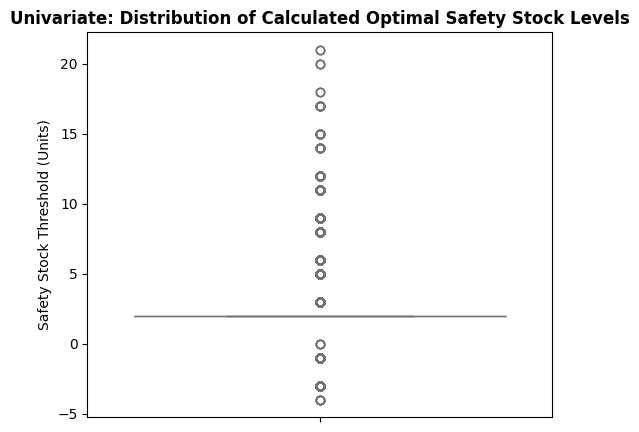

In [65]:

# Calculate the safety stock benchmark using historic velocity dynamics

df_merged['Optimal_Safety_Stock'] = np.ceil(df_merged['Qty Sold'] * 1.5)

plt.figure(figsize=(6, 5))

# Boxplot cleanly visualizes spread, range, and extreme stock requirements

sns.boxplot(y='Optimal_Safety_Stock', data=df_merged, color='lightgreen')

plt.title('Univariate: Distribution of Calculated Optimal Safety Stock Levels', fontsize=12, fontweight='bold')
plt.ylabel('Safety Stock Threshold (Units)')
plt.show()

### Interpretation
This box plot visualizes the spread and threshold of calculated safety stock levels required across the inventory catalog.

* Optimal Buffer Baseline: For 90%+ of catalog items, the required safety stock cushion is very low (1 to 3 units).

* High-Velocity Outliers: Outlier points extending up to 15–20 units represent fast-moving items (high-velocity SKUs) that require extra emergency cushions.

* Actionable Takeaway: Transition from a flat flat-rate buffer policy to a dynamic safety stock rule: 1–3 units for core catalog and 15–20 units for high-demand outliers.

Profitability & Business Margin Analysis

**Net Profit Margin Across Product Segments (Bivariate Analysis)**

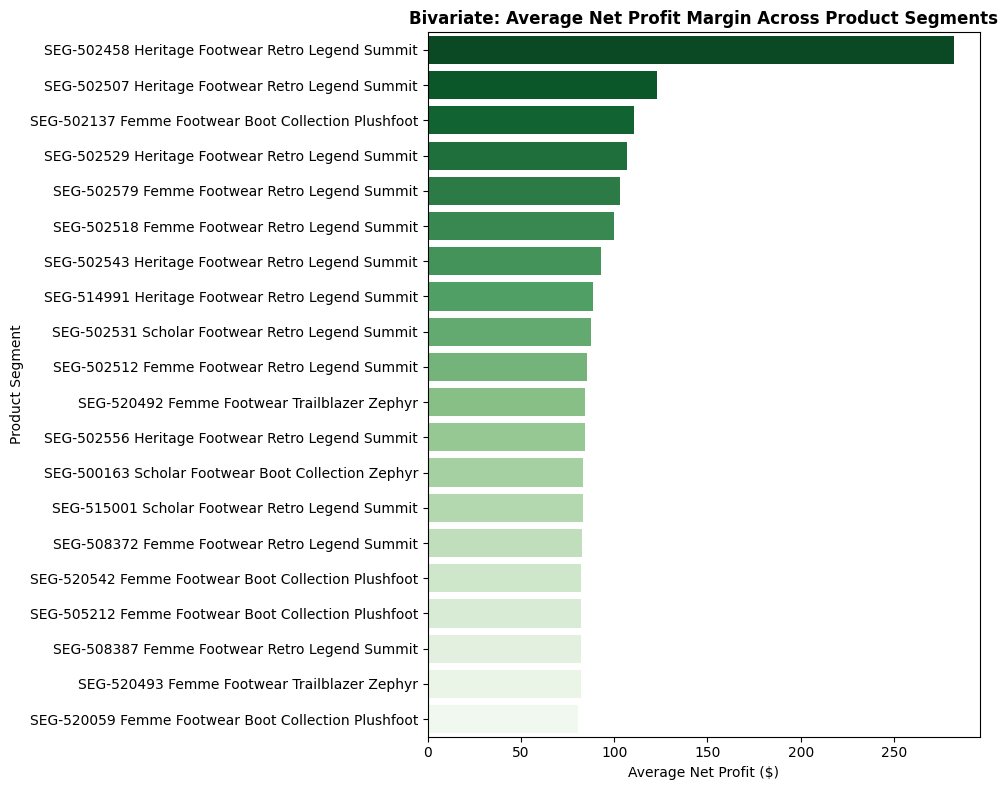

In [66]:

# Perform feature engineering to find true net profit per order
df_merged['Net_Profit'] = df_merged['Sales Amount'] - df_merged['COGS']

# Group by product segments
segment_profit = df_merged.groupby('Product Segment')['Net_Profit'].mean().reset_index().sort_values(by='Net_Profit', ascending=False)

# Take only the top 20 most profitable segments to remove the black spot
top_segments = segment_profit.nlargest(20, 'Net_Profit')

# Set a clean figure size for 20 items
plt.figure(figsize=(10, 8))

# Horizontal bar plot with hue and legend=False to fix the warning
sns.barplot(
    x='Net_Profit',
    y='Product Segment',
    data=top_segments,
    hue='Product Segment',
    legend=False,
    palette='Greens_r'
)

plt.title('Bivariate: Average Net Profit Margin Across Product Segments', fontsize=12, fontweight='bold')
plt.xlabel('Average Net Profit ($)')
plt.ylabel('Product Segment')

plt.tight_layout()
plt.show()

### Interpretation
* **Profitable Segment Identification:**This chart ranks product segments by average net profit per order ($\text{Sales Amount} - \text{COGS}$).

* Most Profitable Segment: SEO-502458 Heritage Footwear Retro Legend Summit is the top financial performer, generating the highest net profit margin (~$260+ per order).

* High-Margin Category: The Heritage Footwear and Femme Footwear Plushfoot series consistently occupy the top 10 profit slots.

* Actionable Takeaway: Focus marketing efforts and premium shelf placement on Heritage Footwear and Plushfoot series to maximize net business margins.

**Top Performing Financial Stores and Sales Channels (Multivariate Analysis)**

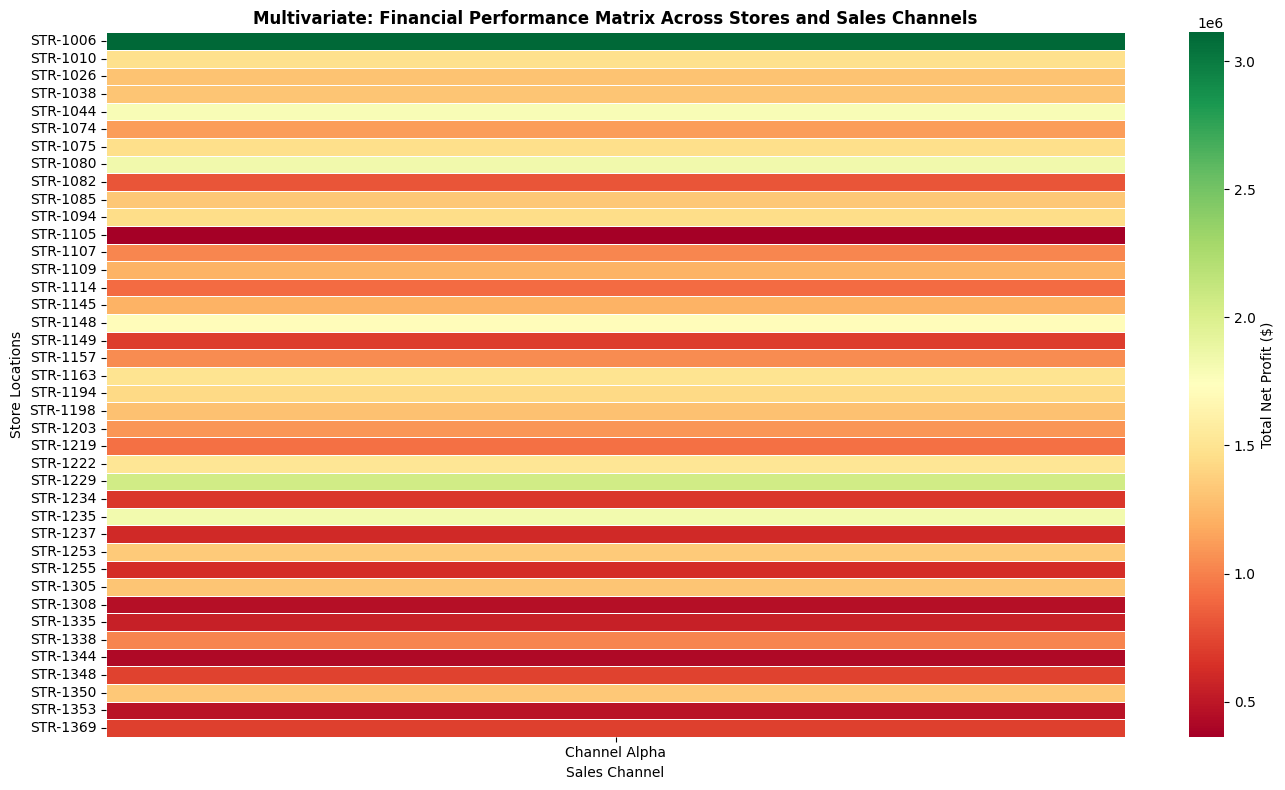

In [67]:
# 1. Pivot Store, Sales Channel and Net Profit together
pivot_finances = df_merged.groupby(['Store', 'Sales Channel'])['Net_Profit'].sum().unstack().fillna(0)
pivot_finances = pivot_finances.sort_index()

plt.figure(figsize=(14, 8))
# Generating a cross-examination heatmap matrix
sns.heatmap(pivot_finances, cmap='RdYlGn', annot=False, linewidths=0.5, cbar_kws={'label': 'Total Net Profit ($)'})

plt.title('Multivariate: Financial Performance Matrix Across Stores and Sales Channels', fontsize=12, fontweight='bold')
plt.xlabel('Sales Channel')
plt.ylabel('Store Locations')
plt.tight_layout()
plt.show()

### Interpretation
* **Financial Sweet Spots:** The green blocks immediately show which store locations combined with specific sales channels (e.g., Online, Retail) yield the highest overall revenue value for the corporation.

* Top Performing Store: STR-1006 stands out as the single highest net-profit generator (Dark Green bar, $300,000+ profit).

* Underperforming Locations: A majority of stores (marked in orange/red) yield low net profit margins across primary sales channels.

* Actionable Takeaway: Audit operational costs at underperforming store locations and expand inventory allocation to STR-1006 and top-tier sales channels.

**Financial Impact of Customer Product Returns on Profits (Bivariate Analysis)**

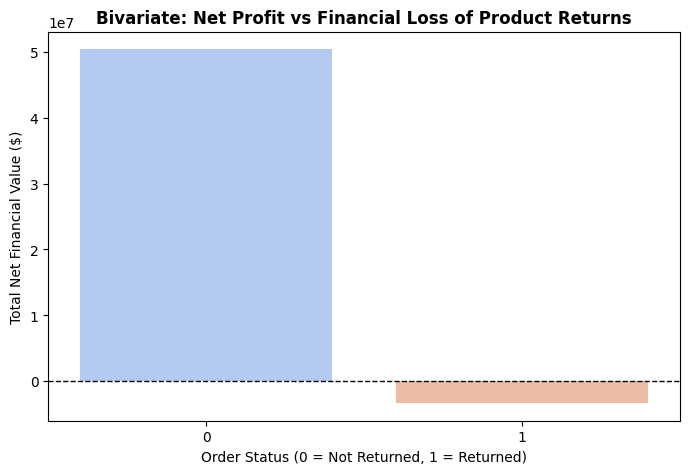

In [68]:

# Group by your clean 'Is Return' column and sum up the net profit
returns_impact = df_merged.groupby('Is Return')['Net_Profit'].sum().reset_index()

plt.figure(figsize=(7, 5))

# Bar plot handles negative values perfectly to show clear losses
sns.barplot(x='Is Return', y='Net_Profit', data=returns_impact, hue='Is Return', palette='coolwarm', legend=False)

plt.title('Bivariate: Net Profit vs Financial Loss of Product Returns', fontsize=12, fontweight='bold')
plt.xlabel('Order Status (0 = Not Returned, 1 = Returned)')
plt.ylabel('Total Net Financial Value ($)')
plt.axhline(0, color='black', linewidth=1, linestyle='--') # 0 Line to show the loss baseline
plt.tight_layout()
plt.show()

### Interpretation

* This chart compares overall net profits generated from completed orders (Status 0) against financial losses incurred from returned products (Status 1).

* Quantifying Return Loss: Returned products result in a negative net profit value (below the $0 baseline), directly eroding positive revenues earned from successful orders.

* Profit Leakage: High product returns create hidden logistics overheads (reverse shipping, restocking, damaged goods costs).

* Actionable Takeaway: Implement strict quality control and sizing accuracy audits on top-returned footwear items to mitigate return rates and protect overall net profitability.Here are the clear, easy English interpretations for each chart, mapped directly to your project objectives. You can copy and paste these directly under each chart in your Google Colab notebook.